In [26]:
from clouddrift.datasets import gdp1h
from pathlib import Path
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ds = gdp1h()
ds

<xarray.Dataset> Size: 16GB
Dimensions:                (traj: 19396, obs: 197214787)
Coordinates:
    id                     (traj) int64 155kB ...
    time                   (obs) datetime64[ns] 2GB ...
Dimensions without coordinates: traj, obs
Data variables: (12/58)
    BuoyTypeManufacturer   (traj) |S20 388kB ...
    BuoyTypeSensorArray    (traj) |S20 388kB ...
    CurrentProgram         (traj) float64 155kB ...
    DeployingCountry       (traj) |S20 388kB ...
    DeployingShip          (traj) |S20 388kB ...
    DeploymentComments     (traj) int16 39kB ...
    ...                     ...
    start_lat              (traj) float32 78kB ...
    start_lon              (traj) float32 78kB ...
    typebuoy               (traj) |S10 194kB ...
    typedeath              (traj) int8 19kB ...
    ve                     (obs) float32 789MB ...
    vn                     (obs) float32 789MB ...
Attributes: (12/18)
    Conventions:          CF-1.6
    acknowledgement:      Elipot, Shane; Sykulski, Adam; Lumpkin, Rick; Centu...
    contributor_name:     NOAA Global Drifter Program
    contributor_role:     Data Acquisition Center
    date_created:         2024-07-30T19:02:16.200531
    doi:                  10.25921/x46c-3620
    ...                   ...
    publisher_name:       GDP Drifter DAC
    publisher_url:        https://www.aoml.noaa.gov/phod/gdp
    summary:              Global Drifter Program hourly data
    time_coverage_end:    2022-10-31:00:00:00Z
    time_coverage_start:  1987-10-02:13:00:00Z
    title:                Global Drifter Program hourly drifting buoy collection

In [27]:
print("Dimensions:")
print(ds.sizes)
print("\nNumber of variables:")
print(len(ds.data_vars))

Dimensions:
Frozen({'traj': 19396, 'obs': 197214787})

Number of variables:
58


In [28]:
# Summary of all variables, including coordinates
all_vars = list(ds.variables)

variable_summary = pd.DataFrame({
    "variable": all_vars,
    "dimensions": [str(ds[var].dims) for var in all_vars],
    "dtype": [str(ds[var].dtype) for var in all_vars],
    "description": [
        ds[var].attrs.get("long_name", "")
        for var in all_vars
    ]
})

variable_summary

,variable,dimensions,dtype,description
0,BuoyTypeManufacturer,"('traj',)",|S20,Buoy type manufacturer
1,BuoyTypeSensorArray,"('traj',)",|S20,Buoy type sensor array
2,CurrentProgram,"('traj',)",float64,Current Program
3,DeployingCountry,"('traj',)",|S20,Deploying country
4,DeployingShip,"('traj',)",|S20,Name of deployment ship
5,DeploymentComments,"('traj',)",int16,Deployment comments
6,DeploymentStatus,"('traj',)",|S20,Deployment status
7,DragAreaAboveDrogue,"('traj',)",float32,Drag area above drogue.
8,DragAreaOfDrogue,"('traj',)",float32,Drag area drogue.
9,DragAreaRatio,"('traj',)",float32,Drag area ratio


In [29]:
# Check the relationship between trajectories and observations
rowsize = ds["rowsize"].values

print("Trajectory length summary")
print("-------------------------")
print(f"Number of trajectories: {len(rowsize):,}")
print(f"Minimum observations:    {rowsize.min():,}")
print(f"Median observations:     {np.median(rowsize):,.0f}")
print(f"Mean observations:       {rowsize.mean():,.1f}")
print(f"Maximum observations:    {rowsize.max():,}")

print("\nSanity check")
print("-------------------------")
print(f"Sum of rowsize: {rowsize.sum():,}")
print(f"Total observations: {ds.sizes['obs']:,}")
print(f"Match: {rowsize.sum() == ds.sizes['obs']}")

Trajectory length summary
-------------------------
Number of trajectories: 19,396
Minimum observations:    13
Median observations:     7,056
Mean observations:       10,167.8
Maximum observations:    70,733

Sanity check
-------------------------
Sum of rowsize: 197,214,787
Total observations: 197,214,787
Match: True


Initial data understanding. The dataset contains 19,396 trajectories and 197,214,787 hourly observations. Trajectory lengths vary substantially, with a median of 7,056 observations and a mean of 10,167.8 observations per trajectory. The sum of rowsize exactly matches the total number of observations, confirming the contiguous ragged-array structure of the dataset. Since observations within the same trajectory are repeated measurements from the same drifter, observation counts should not be interpreted as independent sample sizes.

In [30]:
# Initial Gulf Stream study region
WEST, EAST = -80, -50
SOUTH, NORTH = 25, 45

in_region = (
    (ds["lon"] >= WEST) &
    (ds["lon"] <= EAST) &
    (ds["lat"] >= SOUTH) &
    (ds["lat"] <= NORTH)
)

In [31]:
cache_dir = Path("../data/processed")
cache_dir.mkdir(parents=True, exist_ok=True)

# Convert to NumPy boolean array
in_region_np = np.asarray(in_region.values, dtype=bool)

print("Shape:", in_region_np.shape)
print("dtype:", in_region_np.dtype)
print("Observations in region:", in_region_np.sum())

Shape: (197214787,)
dtype: bool
Observations in region: 8142739


In [32]:
np.save(
    cache_dir / "gulf_stream_in_region.npy",
    in_region_np
)

print("Saved!")

Saved!


In [33]:
n_region_obs = in_region.sum().item()
print(f"Observation in Gulf Stream region: {n_region_obs:,}")
print(f"Total observations: {ds.sizes['obs']:,}")
print(f"Percentage in region: {n_region_obs /ds.sizes['obs'] * 100:.2f}%")

Observation in Gulf Stream region: 8,142,739
Total observations: 197,214,787
Percentage in region: 4.13%


In [34]:
rowsize = ds["rowsize"].values
traj_end = np.cumsum(rowsize)
traj_start = np.concatenate(([0], traj_end[:-1]))
region_mask = in_region.values
traj_in_region = np.array([
    region_mask[start:end].any()
    for start, end in zip(traj_start, traj_end)
])

n_region_traj = traj_in_region.sum()

print(f"Distinct trajectories entering region: {n_region_traj:,}")
print(f"Total trajectories: {ds.sizes['traj']:,}")
print(f"Percentage entering region: {n_region_traj / ds.sizes['traj'] * 100:.2f}%")

Distinct trajectories entering region: 1,482
Total trajectories: 19,396
Percentage entering region: 7.64%


In [35]:
# Extract coordinates of observations inside the study region
lon_region = ds["lon"].values[region_mask]
lat_region = ds["lat"].values[region_mask]

print(f"Regional observations: {len(lon_region):,}")
print(f"Longitude range: {lon_region.min():.2f} to {lon_region.max():.2f}")
print(f"Latitude range:  {lat_region.min():.2f} to {lat_region.max():.2f}")

Regional observations: 8,142,739
Longitude range: -80.00 to -50.00
Latitude range:  25.00 to 45.00


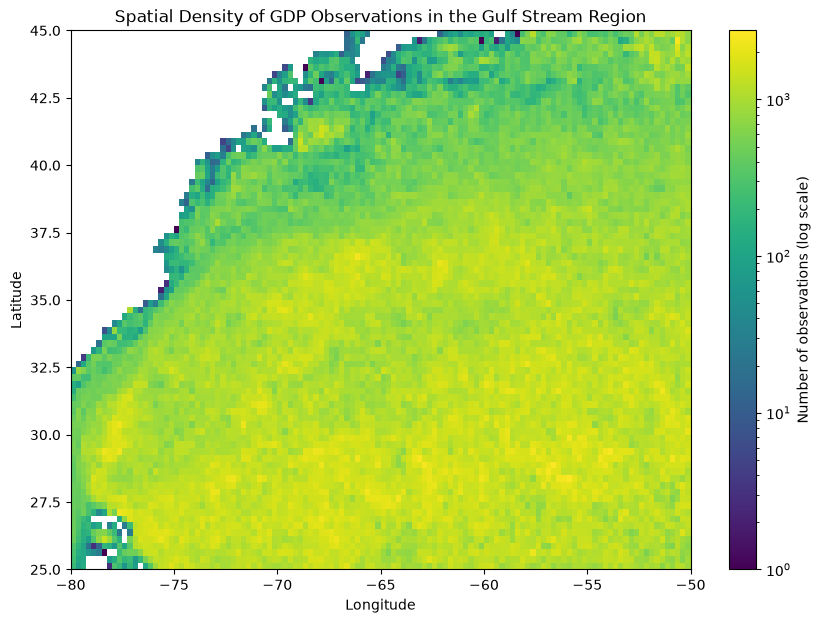

In [36]:
# Spatial observation density

plt.figure(figsize=(10, 7))

plt.hist2d(
    lon_region,
    lat_region,
    bins=[120, 80],
    range=[[WEST, EAST], [SOUTH, NORTH]],
    norm="log"
)

plt.colorbar(label="Number of observations (log scale)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Density of GDP Observations in the Gulf Stream Region")

plt.xlim(WEST, EAST)
plt.ylim(SOUTH, NORTH)

plt.show()

In [37]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

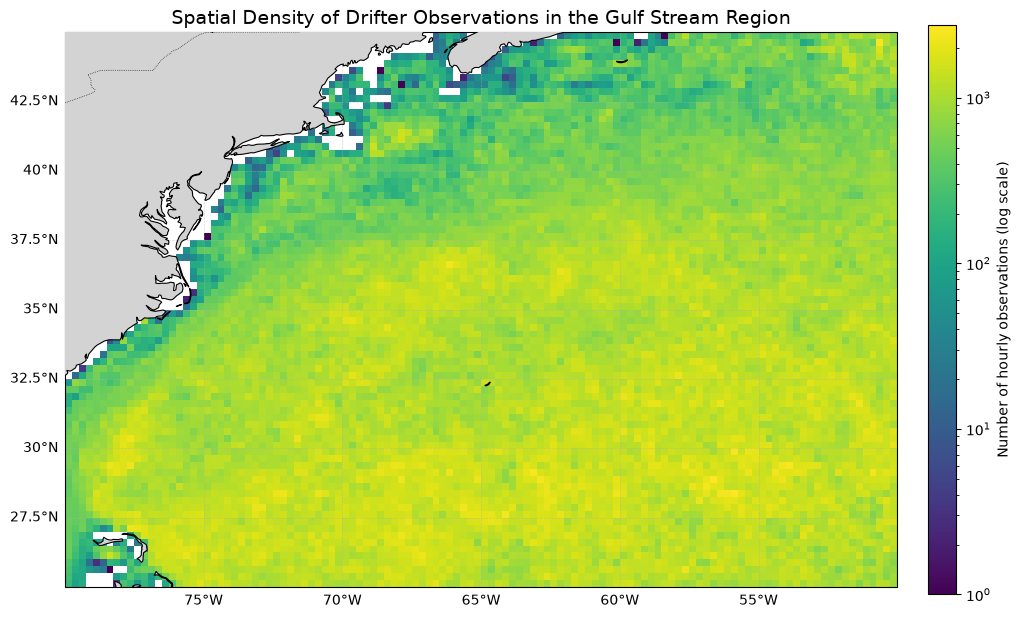

In [38]:
from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Study region
ax.set_extent(
    [WEST, EAST, SOUTH, NORTH],
    crs=ccrs.PlateCarree()
)

# 2D observation density
density = ax.hist2d(
    lon_region,
    lat_region,
    bins=[120, 80],
    range=[[WEST, EAST], [SOUTH, NORTH]],
    norm=LogNorm(),
    transform=ccrs.PlateCarree()
)

# Land and coastline
ax.add_feature(
    cfeature.LAND,
    facecolor="lightgray",
    zorder=3
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.8,
    zorder=4
)

# Country borders for geographic context
ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.5,
    linestyle=":",
    zorder=4
)

# Longitude / latitude grid
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

# Colour bar
cbar = plt.colorbar(
    density[3],
    ax=ax,
    pad=0.03,
    shrink=0.85
)

cbar.set_label("Number of hourly observations (log scale)")

ax.set_title(
    "Spatial Density of Drifter Observations in the Gulf Stream Region",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Project Objective: Predicting Where a Drifter Goes Next

Based on the initial data-coverage analysis, we will focus on **Project IV: predicting future drifter locations in the Gulf Stream region**.

Our initial study region is defined as **80°W–50°W and 25°N–45°N**. Within this region, the GDP hourly dataset contains **8,142,739 observations from 1,482 distinct drifter trajectories**, providing substantial spatial coverage for investigating short-term trajectory prediction.

### Objective

Given a drifter's recent trajectory and current state, we aim to predict its future location over short forecast horizons and evaluate how prediction error changes with lead time.

The predictive model will be compared against two baseline approaches:

1. **Persistence baseline:** extrapolate the drifter's motion using its recent/current velocity.
2. **Mean-flow baseline:** predict movement using the estimated climatological mean surface flow in the region.

Model performance will be evaluated on **held-out drifter trajectories**, rather than randomly splitting individual observations, to reduce information leakage between training and evaluation data.

### Next Steps

The next stage of exploratory analysis will assess the feasibility of this objective, including temporal coverage, trajectory continuity, availability of velocity measurements, drogue status, and the number of usable history–forecast pairs at different lead times.

In [39]:
# Check the variables currently available in the notebook
for name in [
    "ds",
    "in_region",
    "rowsize",
    "traj_id_per_obs",
    "traj_idx_per_obs",
    "obs_to_traj"
]:
    if name in globals():
        obj = globals()[name]
        print(
            name,
            type(obj),
            getattr(obj, "shape", None),
            getattr(obj, "dtype", None)
        )

ds <class 'xarray.core.dataset.Dataset'> None None
in_region <class 'xarray.core.dataarray.DataArray'> (197214787,) bool
rowsize <class 'numpy.ndarray'> (19396,) int32


In [40]:
print(ds)

<xarray.Dataset> Size: 16GB
Dimensions:                (traj: 19396, obs: 197214787)
Coordinates:
    id                     (traj) int64 155kB ...
    time                   (obs) datetime64[ns] 2GB ...
Dimensions without coordinates: traj, obs
Data variables: (12/58)
    BuoyTypeManufacturer   (traj) |S20 388kB ...
    BuoyTypeSensorArray    (traj) |S20 388kB ...
    CurrentProgram         (traj) float64 155kB ...
    DeployingCountry       (traj) |S20 388kB ...
    DeployingShip          (traj) |S20 388kB ...
    DeploymentComments     (traj) int16 39kB ...
    ...                     ...
    start_lat              (traj) float32 78kB ...
    start_lon              (traj) float32 78kB ...
    typebuoy               (traj) |S10 194kB ...
    typedeath              (traj) int8 19kB ...
    ve                     (obs) float32 789MB ...
    vn                     (obs) float32 789MB ...
Attributes: (12/18)
    Conventions:          CF-1.6
    acknowledgement:      Elipot, Shane; Sykuls

In [41]:
for name in ds.data_vars:
    if (
        name in ["lon", "lat", "ve", "vn", "rowsize"]
        or "drog" in name.lower()
    ):
        print(
            f"{name:25s}",
            ds[name].dims,
            ds[name].dtype
        )

DragAreaAboveDrogue       ('traj',) float32
DragAreaOfDrogue          ('traj',) float32
DrogueBallast             ('traj',) float32
DrogueCenterDepth         ('traj',) float32
DrogueDetectSensor        ('traj',) |S20
DrogueLength              ('traj',) float32
DrogueType                ('traj',) |S7
drogue_lost_date          ('traj',) datetime64[ns]
drogue_status             ('obs',) bool
lat                       ('obs',) float64
lon                       ('obs',) float64
rowsize                   ('traj',) int32
ve                        ('obs',) float32
vn                        ('obs',) float32


In [42]:
rowsize = ds["rowsize"].values
traj_ids = ds["id"].values

print(rowsize.shape)
print(traj_ids.shape)
print(rowsize.sum())

(19396,)
(19396,)
197214787


In [43]:
in_region = np.load("../data/processed/gulf_stream_in_region.npy")

print(type(in_region))
print(in_region.shape)
print(in_region.dtype)
print(in_region.sum())

<class 'numpy.ndarray'>
(197214787,)
bool
8142739


In [44]:
ends = np.cumsum(rowsize)
starts = ends - rowsize

regional_traj_ids = []

for traj_id, start, end in zip(traj_ids, starts, ends):
    n_regional = in_region[start:end].sum()

    if n_regional > 0:
        regional_traj_ids.append(
            np.full(n_regional, traj_id, dtype=traj_ids.dtype)
        )

regional_traj_ids = np.concatenate(regional_traj_ids)

print("Regional observations:", len(regional_traj_ids))
print("Distinct trajectories:", np.unique(regional_traj_ids).size)

Regional observations: 8142739
Distinct trajectories: 1482


In [45]:
traj_has_region = np.array([
    in_region[start:end].any()
    for start, end in zip(starts, ends)
])

print("Trajectories passing through region:", traj_has_region.sum())

n_selected_obs = rowsize[traj_has_region].sum()

print("All observations from these trajectories:",
      f"{n_selected_obs:,}")

print("Percentage of global dataset:",
      f"{n_selected_obs / rowsize.sum() * 100:.2f}%")

Trajectories passing through region: 1482
All observations from these trajectories: 20,216,717
Percentage of global dataset: 10.25%


In [46]:
selected_obs = np.repeat(traj_has_region, rowsize)

print("Shape:", selected_obs.shape)
print("dtype:", selected_obs.dtype)
print("Selected observations:", selected_obs.sum())

Shape: (197214787,)
dtype: bool
Selected observations: 20216717


In [48]:
import pandas as pd
import numpy as np
from pathlib import Path
import gc

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# 1. trajectory_id
# --------------------------------------------------
print("Creating trajectory IDs...")

selected_traj_ids = np.repeat(
    traj_ids[traj_has_region],
    rowsize[traj_has_region]
)

print(f"trajectory_id: {len(selected_traj_ids):,}")

# --------------------------------------------------
# 2. Create dataframe
# --------------------------------------------------
df = pd.DataFrame({
    "trajectory_id": selected_traj_ids
})

del selected_traj_ids
gc.collect()

# --------------------------------------------------
# 3. Extract observation-level variables
# --------------------------------------------------
variables = ["time", "lon", "lat", "ve", "vn", "sst","drogue_status"]

for var in variables:
    print(f"Loading {var}...")

    values = ds[var].values
    df[var] = values[selected_obs]

    del values
    gc.collect()

    print(f"  saved {len(df[var]):,} rows")

# --------------------------------------------------
# 4. Add in_region flag
# --------------------------------------------------
df["in_region"] = in_region[selected_obs]

print("\nFinal shape:", df.shape)
print("Trajectories:", df["trajectory_id"].nunique())
print("Regional observations:", df["in_region"].sum())

# --------------------------------------------------
# 5. Save
# --------------------------------------------------
output_path = processed_dir / "gulf_stream_trajectories.parquet"

df.to_parquet(
    output_path,
    index=False,
    compression="snappy"
)

print("\nSaved to:", output_path)

size_mb = output_path.stat().st_size / 1024**2
print(f"File size: {size_mb:.1f} MB")

Creating trajectory IDs...
trajectory_id: 20,216,717
Loading time...
  saved 20,216,717 rows
Loading lon...
  saved 20,216,717 rows
Loading lat...
  saved 20,216,717 rows
Loading ve...
  saved 20,216,717 rows
Loading vn...
  saved 20,216,717 rows
Loading sst...
  saved 20,216,717 rows
Loading drogue_status...
  saved 20,216,717 rows

Final shape: (20216717, 9)
Trajectories: 1482
Regional observations: 8142739

Saved to: ../data/processed/gulf_stream_trajectories.parquet
File size: 448.2 MB


## Study period selection: quarterly Gulf Stream coverage

To define a fixed calendar study period, we compare Gulf Stream drifter
coverage across year-quarters from 1987 to 2022.

For each quarter, we calculate:

- the number of distinct trajectories with at least one observation inside
  the Gulf Stream study region; and
- the total number of observations inside the region.

The aim is not simply to select the quarter with the largest sample, but to
identify a sufficiently well-covered and relatively modern period suitable
for short-horizon trajectory prediction.